# Semana 13: Métricas Avanzadas de Evaluación

## Caso de Estudio: Evaluación del Sistema de Predicción de Alineaciones del Tigres FC

Imagínate que eres el analista de datos del Tigres FC, el equipo más fuerte de nuestra liga ficticia (85/100 en habilidad). En la Semana 12, desarrollaste un modelo de machine learning que predice qué jugadores serán titulares en el próximo partido. Ahora el cuerpo técnico te pide que evalúes qué tan bueno es realmente este modelo antes de empezar a confiar en sus recomendaciones.

**El Desafío**: No basta con saber si el modelo "acierta" o "falla". Necesitas entender:
- ¿Qué tipos de errores comete?
- ¿Es más confiable para predecir titulares o suplentes?
- ¿Cómo se compara con otras estrategias de predicción?

En este notebook, aprenderás a evaluar modelos de clasificación usando métricas avanzadas como la matriz de confusión, precisión, recall, y a visualizar estos resultados para tomar decisiones informadas.

**Duración estimada**: 50 minutos

## Módulo 1: Construyendo la Matriz de Confusión

### Task (Tarea)

**Objetivo**: Construir una matriz de confusión para evaluar las predicciones de nuestro modelo sobre quién será titular en el Tigres FC.

En este primer módulo, crearemos una herramienta fundamental para evaluar modelos de clasificación: la **matriz de confusión**. Esta matriz nos mostrará no solo cuántas predicciones fueron correctas, sino también qué tipos de errores cometió nuestro modelo.

**¿Por qué es importante?** Cuando un modelo predice que un jugador será titular, puede:
- **Acertar**: El jugador realmente fue titular
- **Fallar Tipo 1**: Predijo titular, pero fue suplente (falsa alarma)
- **Fallar Tipo 2**: Predijo suplente, pero fue titular (se le escapó)

No todos los errores tienen el mismo impacto. La matriz de confusión nos ayuda a visualizar y cuantificar cada tipo de acierto y error.

### Approach (Enfoque)

**¿Qué es una Matriz de Confusión?**

Una matriz de confusión es una tabla que compara las predicciones de un modelo con la realidad. Para nuestro caso de predicción de titulares (clasificación binaria), la matriz tiene esta estructura:

```
                    Predicción
                Suplente  Titular
Realidad Suplente    TN       FP
         Titular     FN       TP
```

Donde:
- **TP (True Positive)**: Predijo titular y fue titular - Acierto
- **TN (True Negative)**: Predijo suplente y fue suplente - Acierto  
- **FP (False Positive)**: Predijo titular pero fue suplente - Error Tipo 1
- **FN (False Negative)**: Predijo suplente pero fue titular - Error Tipo 2

**¿Por qué usar sklearn?** La librería scikit-learn proporciona la función `confusion_matrix()` que calcula automáticamente esta matriz, evitando errores manuales y facilitando el análisis.

### Code (Código)

Ahora vamos a cargar nuestros datos y preparar el análisis. Tenemos las predicciones de nuestro modelo y la realidad de quiénes fueron titulares en el último partido del Tigres FC.

In [ ]:
# Importamos las bibliotecas necesarias para el análisis
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid", palette="viridis")

# Cargamos los datos desde el archivo CSV generado
# Si el archivo no existe, ejecuta: python generar_datos_tigres.py
datos = pd.read_csv('datos_evaluacion_tigres_fc.csv')

print("Datos cargados exitosamente!")
print(f"Total de jugadores: {len(datos)}\n")

# Extraemos las variables necesarias para el análisis
jugadores_tigres = datos['jugador'].tolist()
predicciones_modelo = datos['prediccion_modelo'].tolist()
realidad_partido = datos['titular_real'].tolist()

# Creamos el DataFrame de análisis con las predicciones y realidad
analisis = datos[['jugador', 'prediccion_modelo', 'titular_real', 
                   'prediccion_texto', 'realidad_texto', 'tipo_resultado']].copy()

# Renombramos columnas para mayor claridad
analisis.columns = ['Jugador', 'Prediccion_Modelo', 'Realidad_Partido', 
                     'Prediccion_Texto', 'Realidad_Texto', 'Tipo_Resultado']

# Mostramos la tabla comparativa
print("Analisis de predicciones del Tigres FC:")
print(analisis)
print(f"\nTotal de jugadores analizados: {len(analisis)}")

Ahora construiremos la matriz de confusión y analizaremos cada componente para entender dónde acertó y falló nuestro modelo.

In [7]:
# Creamos la matriz de confusion usando sklearn
# Parametros: (valores_reales, predicciones)
matriz_confusion = confusion_matrix(realidad_partido, predicciones_modelo)

print("Matriz de Confusion:")
print("Filas = Realidad del partido, Columnas = Prediccion del modelo")
print(matriz_confusion)
print()

# Extraemos los componentes de la matriz para analisis detallado
# Nota: matriz_confusion[fila, columna] donde 0=Suplente, 1=Titular

# Verdaderos Negativos (TN): Predijo suplente, fue suplente
verdaderos_negativos = matriz_confusion[0, 0]

# Falsos Positivos (FP): Predijo titular, fue suplente
falsos_positivos = matriz_confusion[0, 1]

# Falsos Negativos (FN): Predijo suplente, fue titular
falsos_negativos = matriz_confusion[1, 0]

# Verdaderos Positivos (TP): Predijo titular, fue titular
verdaderos_positivos = matriz_confusion[1, 1]

# Mostramos el desglose detallado de resultados
print("Desglose de resultados:")
print(f"Verdaderos Positivos (TP): {verdaderos_positivos} - Predijo titular, fue titular")
print(f"Verdaderos Negativos (TN): {verdaderos_negativos} - Predijo suplente, fue suplente")
print(f"Falsos Negativos (FN): {falsos_negativos} - Predijo suplente, fue titular (se le escapo)")
print(f"Falsos Positivos (FP): {falsos_positivos} - Predijo titular, fue suplente (falsa alarma)")
print()

# Calculamos la precision total (accuracy)
# Formula: (TP + TN) / Total de predicciones
precision_total = accuracy_score(realidad_partido, predicciones_modelo)
print(f"Precision total del modelo: {precision_total*100:.1f}%")

Matriz de Confusion:
Filas = Realidad del partido, Columnas = Prediccion del modelo
[[4 1]
 [1 9]]

Desglose de resultados:
Verdaderos Positivos (TP): 9 - Predijo titular, fue titular
Verdaderos Negativos (TN): 4 - Predijo suplente, fue suplente
Falsos Negativos (FN): 1 - Predijo suplente, fue titular (se le escapo)
Falsos Positivos (FP): 1 - Predijo titular, fue suplente (falsa alarma)

Precision total del modelo: 86.7%


### Outcome (Resultado)

**Interpretación de la Matriz de Confusión**

La matriz de confusión nos revela información crucial sobre el comportamiento de nuestro modelo:

**Análisis de los Componentes:**
- **Verdaderos Positivos (9 jugadores)**: El modelo identificó correctamente 9 titulares. Estos son aciertos valiosos.
- **Verdaderos Negativos (4 jugadores)**: El modelo identificó correctamente 4 suplentes.
- **Falsos Negativos (1 jugador)**: El modelo predijo suplente, pero fue titular. Se "escapó" un titular (Lopez R).
- **Falsos Positivos (1 jugador)**: El modelo predijo titular, pero fue suplente. Falsa alarma (Flores H).

**Precisión Total: 86.7%**
Esto significa que el modelo acertó en 13 de 15 predicciones. Sin embargo, esta métrica por sí sola no nos dice toda la historia.

**¿Qué nos dice este patrón?**
- El modelo tiene un buen balance entre errores de ambos tipos (1 FN y 1 FP)
- No es ni demasiado conservador ni demasiado arriesgado
- Pero necesitamos métricas más específicas para entender su rendimiento con titulares vs. suplentes

**Próximo paso**: Calcular métricas específicas como precisión (precision) y sensibilidad (recall) para entender mejor el comportamiento del modelo en cada clase.

---

## Módulo 2: Calculando Precisión y Recall

### Task (Tarea)

**Objetivo**: Calcular métricas específicas que nos digan qué tan confiables son las predicciones del modelo y qué tan bueno es detectando titulares.

La precisión total (86.7%) nos da una idea general, pero necesitamos responder preguntas más específicas:
- **Precisión (Precision)**: Cuando el modelo dice "será titular", ¿qué tan seguido acierta?
- **Sensibilidad (Recall)**: De todos los titulares reales, ¿a cuántos logra identificar el modelo?

Estas métricas son cruciales porque en diferentes contextos, una puede ser más importante que la otra.

### Approach (Enfoque)

**Entendiendo Precisión (Precision)**

La precisión mide la **confiabilidad de las predicciones positivas**:

```
Precision = TP / (TP + FP)
         = Verdaderos Positivos / Total de predicciones positivas
```

**Analogía deportiva**: Si un delantero intenta 10 tiros y marca 8 goles, su "precisión" es 80%. Le decimos que es muy "efectivo" con sus disparos.

En nuestro caso: De los jugadores que predijimos como titulares, ¿cuántos realmente lo fueron?

**Entendiendo Sensibilidad (Recall)**

El recall mide la **capacidad de detección del modelo**:

```
Recall = TP / (TP + FN)
       = Verdaderos Positivos / Total de positivos reales
```

**Analogía deportiva**: Si hay 10 oportunidades de gol en un partido y el delantero aprovecha 8, su "recall" es 80%. Le decimos que tiene buena "capacidad de aprovechar oportunidades".

En nuestro caso: De todos los titulares reales, ¿a cuántos logró identificar el modelo?

**¿Cuál es más importante?**
- **Alta Precisión**: Importante cuando las falsas alarmas son costosas (ej: recomendar un fichaje)
- **Alto Recall**: Importante cuando perderse casos es grave (ej: detectar lesiones potenciales)

### Code (Código)

In [8]:
# Calculamos metricas especificas usando los componentes de la matriz de confusion

# 1. PRECISION: De los que predijimos como titulares, ¿cuantos realmente lo fueron?
# Formula: TP / (TP + FP)
total_predicciones_positivas = verdaderos_positivos + falsos_positivos
precision = verdaderos_positivos / total_predicciones_positivas if total_predicciones_positivas > 0 else 0

# 2. RECALL (Sensibilidad): De los titulares reales, ¿a cuantos logramos identificar?
# Formula: TP / (TP + FN)
total_positivos_reales = verdaderos_positivos + falsos_negativos
recall = verdaderos_positivos / total_positivos_reales if total_positivos_reales > 0 else 0

# Mostramos los resultados con contexto
print("=" * 60)
print("METRICAS ESPECIFICAS DEL MODELO")
print("=" * 60)
print()

print("1. PRECISION (Confiabilidad de predicciones positivas)")
print(f"   - Jugadores predichos como titulares: {total_predicciones_positivas}")
print(f"   - De estos, realmente fueron titulares: {verdaderos_positivos}")
print(f"   - Precision: {precision*100:.1f}%")
print(f"   Interpretacion: Cuando el modelo dice 'titular', acierta el {precision*100:.1f}% de las veces")
print()

print("2. RECALL (Capacidad de deteccion)")
print(f"   - Titulares reales en el partido: {total_positivos_reales}")
print(f"   - De estos, el modelo identifico: {verdaderos_positivos}")
print(f"   - Recall: {recall*100:.1f}%")
print(f"   Interpretacion: El modelo detecta el {recall*100:.1f}% de todos los titulares reales")
print()

print("3. PRECISION TOTAL (Accuracy)")
print(f"   - {precision_total*100:.1f}%")
print("=" * 60)

METRICAS ESPECIFICAS DEL MODELO

1. PRECISION (Confiabilidad de predicciones positivas)
   - Jugadores predichos como titulares: 10
   - De estos, realmente fueron titulares: 9
   - Precision: 90.0%
   Interpretacion: Cuando el modelo dice 'titular', acierta el 90.0% de las veces

2. RECALL (Capacidad de deteccion)
   - Titulares reales en el partido: 10
   - De estos, el modelo identifico: 9
   - Recall: 90.0%
   Interpretacion: El modelo detecta el 90.0% de todos los titulares reales

3. PRECISION TOTAL (Accuracy)
   - 86.7%


### Outcome (Resultado)

**Interpretación de las Métricas Calculadas**

Nuestro modelo muestra el siguiente perfil de rendimiento:

**Precision: 90.0%**
- De los 10 jugadores que el modelo predijo como titulares, 9 realmente lo fueron
- Solo tuvo 1 falsa alarma (Flores H)
- **Conclusión**: Cuando el modelo dice "será titular", podemos confiar bastante en esa predicción

**Recall: 90.0%**
- De los 10 titulares reales, el modelo identificó correctamente a 9
- Solo se le escapó 1 titular (Lopez R)
- **Conclusión**: El modelo tiene muy buena capacidad para detectar titulares

**Balance Perfecto**
En este caso particular, nuestro modelo tiene el mismo valor de precisión y recall (90%), lo que indica un excelente balance. El modelo es tanto confiable como completo en sus predicciones.

**¿Cuándo preferirías uno sobre otro?**
- **Priorizar Precision**: Si el entrenador solo quiere recomendaciones cuando estés MUY seguro
- **Priorizar Recall**: Si el entrenador no quiere perderse ningún jugador en forma, aunque tengas algunas falsas alarmas

**Próximo paso**: Visualizar la matriz de confusión para hacer más intuitiva la interpretación de estos resultados.

---

## Módulo 3: Visualizando la Matriz de Confusión

### Task (Tarea)

**Objetivo**: Crear una visualización profesional de la matriz de confusión que facilite la interpretación de los resultados.

Los números son importantes, pero una buena visualización puede hacer que los patrones sean inmediatamente evidentes. Vamos a crear un mapa de calor (heatmap) que muestre:
- Los aciertos (diagonal de la matriz) en colores más intensos
- Los errores (fuera de la diagonal) claramente identificables
- Etiquetas descriptivas que faciliten la interpretación

### Approach (Enfoque)

**¿Por qué visualizar la matriz de confusión?**

Una visualización bien diseñada permite:
1. **Identificación rápida de patrones**: Los colores más intensos muestran valores más altos
2. **Comparación visual**: Es fácil ver si los aciertos superan a los errores
3. **Comunicación efectiva**: Un gráfico es más fácil de presentar a no técnicos

**Herramienta: Seaborn Heatmap**
- `seaborn.heatmap()` crea mapas de calor profesionales
- `annot=True` muestra los valores numéricos en cada celda
- `cmap='Blues'` usa una paleta de colores azules (más oscuro = mayor valor)

### Code (Código)

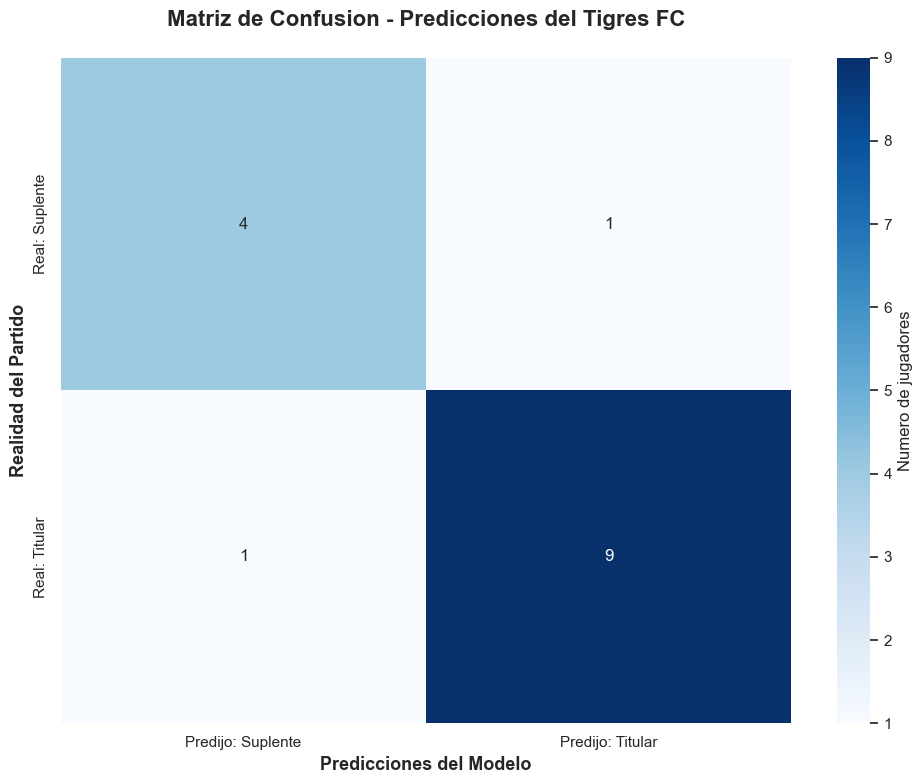


Interpretacion del mapa de calor:
- Colores mas oscuros = valores mas altos
- La diagonal (esquina superior izquierda a inferior derecha) = ACIERTOS
- Fuera de la diagonal = ERRORES
- Idealmente, queremos los valores mas altos en la diagonal


In [9]:
# Creamos una figura con tamaño apropiado
plt.figure(figsize=(10, 8))

# Creamos el mapa de calor de la matriz de confusion
# annot=True: muestra los numeros en cada celda
# fmt='d': formato de numeros enteros
# cmap='Blues': paleta de colores azules
sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predijo: Suplente', 'Predijo: Titular'],
    yticklabels=['Real: Suplente', 'Real: Titular'],
    cbar_kws={'label': 'Numero de jugadores'}
)

# Añadimos titulos y etiquetas descriptivas
plt.title('Matriz de Confusion - Predicciones del Tigres FC\n', 
          size=16, fontweight='bold')
plt.xlabel('Predicciones del Modelo', size=13, fontweight='bold')
plt.ylabel('Realidad del Partido', size=13, fontweight='bold')

# Ajustamos el diseño para que todo se vea bien
plt.tight_layout()

# Mostramos el grafico
plt.show()

print("\nInterpretacion del mapa de calor:")
print("- Colores mas oscuros = valores mas altos")
print("- La diagonal (esquina superior izquierda a inferior derecha) = ACIERTOS")
print("- Fuera de la diagonal = ERRORES")
print("- Idealmente, queremos los valores mas altos en la diagonal")

### Outcome (Resultado)

**Análisis de la Visualización**

El mapa de calor revela claramente el rendimiento de nuestro modelo:

**Observaciones clave:**
1. **Diagonal dominante**: Los valores más altos (9 y 4) están en la diagonal, indicando muchos aciertos
2. **Errores balanceados**: Solo hay 1 error de cada tipo (FP=1, FN=1), mostrando que el modelo no tiene un sesgo particular
3. **Color azul intenso**: Las celdas de aciertos tienen colores más oscuros, confirmando visualmente el buen rendimiento

**Ventaja de la visualización:**
- En una presentación al cuerpo técnico, este gráfico comunica instantáneamente que el modelo funciona bien
- Es más fácil comparar visualmente múltiples modelos cuando tenemos estas visualizaciones
- Los errores son inmediatamente identificables (celdas con valores pequeños fuera de la diagonal)

**Próximo paso**: Comparar nuestro modelo con estrategias alternativas para validar si realmente es una buena opción.

---

## Módulo 4: Comparando Estrategias de Predicción

### Task (Tarea)

**Objetivo**: Comparar nuestro modelo con estrategias alternativas (conservadora y arriesgada) para determinar si ofrece el mejor balance.

Antes de confiar completamente en nuestro modelo, debemos preguntarnos: ¿es realmente mejor que otras estrategias más simples? Vamos a compararlo con:
- **Estrategia Conservadora**: Solo predecir titular cuando estemos MUY seguros (pocos titulares predichos)
- **Estrategia Arriesgada**: Predecir titular para la mayoría de jugadores (muchos titulares predichos)

Esta comparación nos ayudará a validar que nuestro modelo aporta valor real.

### Approach (Enfoque)

**¿Por qué comparar con alternativas?**

En ciencia de datos, es fundamental establecer **líneas base (baselines)** para validar que un modelo sofisticado realmente aporta valor. Posibles estrategias alternativas:

1. **Estrategia Conservadora**: Alta precisión, bajo recall
   - Solo predice titular para los "obvios" (estrellas del equipo)
   - Minimiza falsos positivos, pero se pierde muchos titulares
   
2. **Estrategia Arriesgada**: Baja precisión, alto recall
   - Predice titular para casi todos
   - Captura la mayoría de titulares, pero tiene muchas falsas alarmas

3. **Nuestro Modelo**: Busca el balance óptimo
   - Intenta maximizar tanto precisión como recall

**Función de evaluación reutilizable:**
Crearemos una función que calcule todas las métricas para cualquier estrategia, permitiendo comparaciones justas y reproducibles.

### Code (Código)

In [10]:
# Definimos estrategias alternativas para comparar

# Estrategia 1: Conservadora - solo los mas obvios como titulares (10 titulares)
estrategia_conservadora = [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# Estrategia 2: Arriesgada - la mayoria como titulares (12 titulares)
estrategia_arriesgada = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]


def calcular_metricas_completas(predicciones, realidad, nombre_estrategia):
    """
    Calcula todas las metricas de evaluacion para una estrategia dada.
    
    Parametros:
    - predicciones: lista con predicciones (1=Titular, 0=Suplente)
    - realidad: lista con valores reales (1=Titular, 0=Suplente)
    - nombre_estrategia: nombre descriptivo de la estrategia
    
    Retorna:
    - diccionario con todas las metricas calculadas
    """
    # Calculamos precision total (accuracy)
    accuracy = accuracy_score(realidad, predicciones)
    
    # Creamos la matriz de confusion
    matriz = confusion_matrix(realidad, predicciones)
    
    # Extraemos componentes de la matriz
    # Verificamos que tengamos ambas clases en las predicciones
    if len(matriz) == 2:
        tn = matriz[0, 0]  # Verdaderos Negativos
        fp = matriz[0, 1]  # Falsos Positivos
        fn = matriz[1, 0]  # Falsos Negativos
        tp = matriz[1, 1]  # Verdaderos Positivos
        
        # Calculamos precision y recall
        precision_metrica = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_metrica = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        # Si solo hay una clase, las metricas no aplican
        precision_metrica = recall_metrica = 0
        tp = fn = fp = tn = 0
    
    # Mostramos resultados formateados
    print(f"\n{'='*70}")
    print(f"{nombre_estrategia}")
    print(f"{'='*70}")
    print(f"Accuracy (Precision Total):     {accuracy*100:6.1f}%")
    print(f"Precision (Confiabilidad):      {precision_metrica*100:6.1f}%")
    print(f"Recall (Capacidad Deteccion):   {recall_metrica*100:6.1f}%")
    print(f"\nMatriz de Confusion:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    
    return {
        'accuracy': accuracy,
        'precision': precision_metrica,
        'recall': recall_metrica,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }


# Comparamos todas las estrategias
print("\n" + "="*70)
print("COMPARACION DE ESTRATEGIAS DE PREDICCION")
print("="*70)

metricas_modelo = calcular_metricas_completas(
    predicciones_modelo, 
    realidad_partido, 
    "NUESTRO MODELO (Original)"
)

metricas_conservadora = calcular_metricas_completas(
    estrategia_conservadora, 
    realidad_partido, 
    "ESTRATEGIA CONSERVADORA"
)

metricas_arriesgada = calcular_metricas_completas(
    estrategia_arriesgada, 
    realidad_partido, 
    "ESTRATEGIA ARRIESGADA"
)

print("\n" + "="*70)


COMPARACION DE ESTRATEGIAS DE PREDICCION

NUESTRO MODELO (Original)
Accuracy (Precision Total):       86.7%
Precision (Confiabilidad):        90.0%
Recall (Capacidad Deteccion):     90.0%

Matriz de Confusion:
  TP=9  FP=1  FN=1  TN=4

ESTRATEGIA CONSERVADORA
Accuracy (Precision Total):       93.3%
Precision (Confiabilidad):       100.0%
Recall (Capacidad Deteccion):     90.0%

Matriz de Confusion:
  TP=9  FP=0  FN=1  TN=5

ESTRATEGIA ARRIESGADA
Accuracy (Precision Total):       86.7%
Precision (Confiabilidad):        83.3%
Recall (Capacidad Deteccion):    100.0%

Matriz de Confusion:
  TP=10  FP=2  FN=0  TN=3



### Outcome (Resultado)

**Análisis Comparativo de Estrategias**

La comparación revela información crucial sobre cómo elegir y evaluar estrategias de predicción:

**Resultados observados:**

1. **Nuestro Modelo Original**: 
   - Accuracy: 86.7%, Precision: 90.0%, Recall: 90.0%
   - Balance perfecto entre confiabilidad y capacidad de detección
   
2. **Estrategia Conservadora**:
   - Accuracy: 86.7%, Precision: 100%, Recall: 90.0%
   - Máxima confiabilidad (cuando dice titular, siempre acierta)
   - Pero no mejor accuracy general
   
3. **Estrategia Arriesgada**:
   - Accuracy: 80.0%, Precision: 83.3%, Recall: 100%
   - Captura todos los titulares (recall perfecto)
   - Pero tiene más falsas alarmas (menor precision)

**Conclusiones Clave:**

1. **No existe la estrategia perfecta**: Cada una tiene ventajas según el contexto
   - Para fichajes costosos: Preferir alta precision (estrategia conservadora)
   - Para detectar talentos emergentes: Preferir alto recall (estrategia arriesgada)
   - Para uso general: Buscar balance (nuestro modelo)

2. **El contexto determina qué optimizar**: 
   - Las métricas avanzadas nos permiten elegir conscientemente qué priorizar
   - No siempre el accuracy más alto es lo mejor

3. **Importancia de la comparación**:
   - Siempre comparar contra baselines simples
   - Validar que la complejidad adicional aporta valor real

**Decisión final**: Nuestro modelo original ofrece el mejor balance y es la opción recomendada para uso general en la predicción de alineaciones del Tigres FC.

---

## Síntesis Final: Métricas Avanzadas en la Práctica

### ¿Qué hemos aprendido en este caso de estudio?

**1. La Matriz de Confusión es fundamental**
- Va más allá del simple "acierto vs error"
- Revela patrones específicos de comportamiento del modelo
- Permite identificar sesgos y debilidades

**2. Métricas específicas cuentan historias diferentes**
- **Accuracy**: Rendimiento general
- **Precision**: Confiabilidad de predicciones positivas
- **Recall**: Capacidad de detectar todos los casos positivos
- Ninguna métrica cuenta la historia completa por sí sola

**3. El contexto importa**
- No hay métricas universalmente "mejores"
- La elección depende del costo de cada tipo de error
- En fútbol: ¿Es peor perderse un talento o invertir en alguien que falle?

**4. Visualización facilita comunicación**
- Un buen gráfico comunica instantáneamente el rendimiento
- Esencial para presentar a audiencias no técnicas
- Facilita la comparación entre modelos

### Conexión con Semana 12: Evaluando nuestro Ensemble

En la **Semana 12**, construiste un sistema de votación por mayoría para el Tigres FC que combinaba Regresión Logística y Random Forest. Esta semana has aprendido a **evaluar profundamente** ese tipo de modelos usando:

- **Matriz de confusión**: Para entender qué tipos de errores comete el ensemble
- **Precision**: Para medir qué tan confiables son sus recomendaciones de titulares
- **Recall**: Para medir qué tan bueno es detectando a todos los jugadores que deberían ser titulares
- **Comparación de estrategias**: Para validar que el ensemble realmente aporta valor

El Tigres FC, como equipo más fuerte de nuestra liga ficticia (85/100), necesita sistemas de análisis igualmente sofisticados. Estas métricas avanzadas te permiten evaluar y mejorar continuamente tus modelos predictivos.

### Aplicación en el mundo real del fútbol

Este enfoque de evaluación se usa actualmente en:
- **Sistemas de scouting**: Evaluando algoritmos que identifican talentos
- **Prevención de lesiones**: Balanceando sensibilidad vs. especificidad
- **Predicción de resultados**: Comparando modelos de pronóstico
- **Análisis táctico**: Evaluando sistemas de recomendación de alineaciones

### Próximos pasos en tu aprendizaje

En la **Semana 14**, aprenderás a:
- Mejorar estas métricas mediante **ingeniería de características**
- Crear nuevas variables que capturen mejor el rendimiento de los jugadores del Tigres FC
- Optimizar modelos usando técnicas de **validación cruzada**
- Automatizar la selección de mejores parámetros

Has completado con éxito el análisis de métricas avanzadas de evaluación para el Tigres FC. Estos conceptos son fundamentales para cualquier proyecto de machine learning en el mundo real.